# Actividad 5 — Lionel Messi Club Goals

**Dataset elegido:** `Lionel Messi Club Goals (adaptado)` — 704 goles, 23 columnas.

La actividad son 9 preguntas de opción múltiple. La Parte I es conceptual y sale del
teórico; la Parte II es sobre el dataset. Este notebook deja documentado **cómo se llega
a cada respuesta**: las conceptuales se demuestran ejecutándolas sobre este mismo CSV, y
las del dataset se derivan directamente de los datos.

| # | Pregunta | Respuesta marcada |
|---|---|---|
| 1 | Faltantes 25 % con patrón MAR | Imputar con la media o mediana **considerando el patrón** |
| 2 | Stratified split | Mantiene en train y test **la misma proporción de clases** |
| 3 | Split antes de transformar | Evita que test **contamine** el entrenamiento y dé métricas optimistas |
| 4 | Normalizar antes de KNN | KNN es **sensible a la escala**: los rangos grandes dominan la distancia |
| 5 | Solo en train, no en test | **Balanceo de clases** por oversampling (SMOTE) |
| 6 | `Playing_Position` | **Limpiar** la columna y después codificar |
| 7 | `Opponent` como feature | **Frequency Encoding o Target Encoding** |
| 8 | `Minute_num` por tramos | Discretizar en intervalos de **igual longitud** |
| 9 | Target `Has_Assist` | El dataset está **ligeramente desbalanceado** |

Cada sección cita además la diapositiva del teórico de la que sale la respuesta.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# paleta: azul y naranja (validados para daltonismo y contraste)
AZUL, NARANJA, GRIS = "#2a78d6", "#eb6834", "#8a8984"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
})

df = pd.read_csv("data_messi_full.csv")
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
df.head(3)

Filas: 704 | Columnas: 23


,Season,Competition,Matchday,Date,Venue,Club,Opponent,Result,Playing_Position,Minute,At_score,Type,Goal_assist,Minute_num,Goals_For,Goals_Against,Match_Result,Score_For,Score_Against,Score_Diff,Season_Start,Has_Assist,Set_Piece
0,04/05,LaLiga,34,05-01/05,H,FC Barcelona,Albacete Balompie,2:00,CF,90+1,2:00,Left-footed shot,Ronaldinho Gaacho,91,2,0,Win,2,0,2,2004,1,0
1,05/06,UEFA Champions League,Group Stage,11-02/05,H,FC Barcelona,Panathinaikos Athens,5:00,RW,34,3:00,Left-footed shot,NaN,34,5,0,Win,3,0,3,2005,0,0
2,05/06,LaLiga,13,11/27/05,H,FC Barcelona,Racing Santander,4:01,RW,51,2:00,Left-footed shot,Samuel Etoo,51,4,1,Win,2,0,2,2005,1,0


## 1. Vistazo general

Antes de contestar nada, hay que saber con qué se trabaja: qué tipo tiene cada columna,
dónde hay nulos y si hay filas repetidas.

In [2]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores únicos": df.nunique(),
})
print("Filas duplicadas completas:", df.duplicated().sum())
resumen

Filas duplicadas completas: 0


,tipo,nulos,% nulos,valores únicos
Season,str,0,0.00,19
Competition,str,0,0.00,9
Matchday,str,0,0.00,48
Date,str,0,0.00,455
Venue,str,0,0.00,2
Club,str,0,0.00,2
Opponent,str,0,0.00,98
Result,str,0,0.00,55
Playing_Position,str,0,0.00,9
Minute,str,0,0.00,97


Solo dos columnas tienen nulos: `Goal_assist` con el 30 % y `Type` con uno solo.
Ese 30 % **no es un dato perdido**, es un faltante estructural: el gol no tuvo asistencia.
Se demuestra en la pregunta 9.

# Parte I — Preguntas conceptuales

Las respuestas salen del teórico. Para no contestarlas de memoria, cada una se verifica
ejecutándola sobre el dataset de Messi.

## Pregunta 1 — 25 % de faltantes con patrón MAR

> Un dataset tiene un 25 % de valores faltantes en una variable numérica, y esos faltantes
> siguen un patrón relacionado con otra variable (MAR). ¿Cuál es la estrategia más adecuada?

**Respuesta: imputar con la media o mediana considerando el patrón detectado.**

Sale de la tabla de la diapositiva 21 del deck *05 - Procesamiento y limpieza de datos*,
que cruza el mecanismo del faltante con su porcentaje:

| MAR (patrón) | Muy baja (<10 %) | **Baja (10-30 %)** | Media (40-60 %) | Alta (70 %+) |
|---|---|---|---|---|
| Estrategia | Imputación simple (considerando el patrón) | **Imputación simple (considerando el patrón)** | Técnicas avanzadas | Eliminar columna completa |

El 25 % cae en la franja **Baja (10-30 %)**. Eliminar la columna recién aparece a partir
del 70 %, y eliminar filas es la receta de MCAR con menos del 10 %.

Lo importante es el *"considerando el patrón"*: si los faltantes dependen de otra variable,
imputar con la media global borra ese patrón. Hay que imputar **por grupo**. Se ve abajo
simulando un faltante MAR en este dataset.

Uso `Season_Start` y `Club`, que tienen una relación fuerte: los goles del Barcelona van de
2004 a 2020 y los del PSG de 2021 en adelante.

In [3]:
# Simulo un faltante MAR: escondo el año de temporada con mucha más probabilidad en los
# goles del PSG. La falta depende de otra columna (Club), que es la definición de MAR.
rng = np.random.default_rng(42)
sim = df[["Season_Start", "Club"]].copy()

prob = np.where(sim["Club"] == "Paris Saint-Germain", 0.75, 0.15)
sim["Season_obs"] = sim["Season_Start"].where(rng.random(len(sim)) > prob)

print(f"Faltantes generados: {sim['Season_obs'].isna().mean():.1%}")
print("\n% de faltantes según Club (este es el patrón que detecta el análisis MAR):")
print((sim.groupby("Club")["Season_obs"].apply(lambda s: s.isna().mean()) * 100).round(1))

Faltantes generados: 19.6%

% de faltantes según Club (este es el patrón que detecta el análisis MAR):
Club
FC Barcelona           16.8
Paris Saint-Germain    78.1
Name: Season_obs, dtype: float64


In [4]:
# Dos formas de imputar: la global (ignora el patrón) y la que respeta el patrón.
global_ = sim["Season_obs"].fillna(sim["Season_obs"].mean())
por_grupo = sim["Season_obs"].fillna(sim.groupby("Club")["Season_obs"].transform("mean"))

comparacion = pd.DataFrame({
    "real": sim.groupby("Club")["Season_Start"].mean(),
    "imputación global": global_.groupby(sim["Club"]).mean(),
    "imputación por patrón": por_grupo.groupby(sim["Club"]).mean(),
}).round(2)
comparacion["error global"] = (comparacion["imputación global"] - comparacion["real"]).abs().round(2)
comparacion["error por patrón"] = (comparacion["imputación por patrón"] - comparacion["real"]).abs().round(2)
comparacion

,real,imputación global,imputación por patrón,error global,error por patrón
Club,,,,,
FC Barcelona,2013.32,2013.33,2013.32,0.01,0.00
Paris Saint-Germain,2021.56,2015.23,2021.71,6.33,0.15


Acá se ve por qué la respuesta dice *"considerando el patrón"*. La imputación global le
asigna al PSG un año promedio de 2015, cuando en realidad sus goles son de 2021 en adelante:
**se equivoca por más de 6 años**. La imputación por grupo se equivoca por 0.15.

Una media global no es neutral cuando los faltantes siguen un patrón: inventa un valor que
no existe en ninguno de los dos grupos.

## Pregunta 2 — Stratified split

> ¿Cuál de las siguientes afirmaciones sobre el *stratified split* es correcta?

**Respuesta: mantiene en train y test la misma proporción de clases que existe en el
dataset original.**

Diapositiva 9 del deck *05 - Procesamiento y limpieza de datos*, tarjeta **Clasificación**:
*"Garantiza que las clases del target queden representadas de manera equitativa y
proporcional en ambos subconjuntos. Stratified Split. Esencial para datasets desbalanceados."*

La opción trampa es *"corrige el desbalance"*. **No lo corrige: lo conserva.** Corregir el
desbalance es oversampling o undersampling, que es otra técnica. Se comprueba abajo.

In [5]:
y = df["Has_Assist"]

_, test_sin = train_test_split(y, test_size=0.3, random_state=7)                  # sin estratificar
_, test_con = train_test_split(y, test_size=0.3, random_state=7, stratify=y)      # estratificado

proporciones = pd.DataFrame({
    "dataset original": y.value_counts(normalize=True),
    "test sin estratificar": test_sin.value_counts(normalize=True),
    "test estratificado": test_con.value_counts(normalize=True),
}).mul(100).round(2)
proporciones.index = ["con asistencia (1)", "sin asistencia (0)"]
proporciones

,dataset original,test sin estratificar,test estratificado
con asistencia (1),69.6,68.87,69.81
sin asistencia (0),30.4,31.13,30.19


In [6]:
desvio_sin = (proporciones["test sin estratificar"] - proporciones["dataset original"]).abs().max()
desvio_con = (proporciones["test estratificado"] - proporciones["dataset original"]).abs().max()
print(f"Desvío máximo sin estratificar : {desvio_sin:.2f} puntos porcentuales")
print(f"Desvío máximo estratificado    : {desvio_con:.2f} puntos porcentuales")
print("\nOJO: el estratificado replica la proporción original (69.6 / 30.4).")
print("NO la empareja a 50/50 -> no corrige el desbalance, lo conserva.")

Desvío máximo sin estratificar : 0.73 puntos porcentuales
Desvío máximo estratificado    : 0.21 puntos porcentuales

OJO: el estratificado replica la proporción original (69.6 / 30.4).
NO la empareja a 50/50 -> no corrige el desbalance, lo conserva.


## Pregunta 3 — Por qué hacer el split antes de transformar

> ¿Por qué es importante hacer el split del dataset antes de aplicar cualquier transformación?

**Respuesta: para evitar que la información de los datos de test "contamine" el
entrenamiento y que al evaluar el modelo se obtenga una performance demasiado optimista.**

Es textual de la diapositiva 5 del deck *06 - Procesamiento y nuevas features*, que tiene
dos tarjetas: **Contaminación de Datos** (*"estaríamos contaminando el dataset de
entrenamiento con pistas de los datos de test"*) y **Métricas Engañosas**
(*"las métricas serían engañosas, demasiado optimistas"*).

Abajo se ve la fuga concreta: si el mínimo y el máximo para normalizar se calculan sobre
el dataset completo, esos dos números ya traen información del test.

In [7]:
X = df[["Minute_num"]]
X_train, X_test = train_test_split(X, test_size=0.3, random_state=1)

fuga = pd.DataFrame({
    "calculado sobre TODO (mal)": [X["Minute_num"].min(), X["Minute_num"].max()],
    "calculado solo en TRAIN (bien)": [X_train["Minute_num"].min(), X_train["Minute_num"].max()],
}, index=["mínimo", "máximo"])
print(fuga, "\n")

print(f"Máximo que hay en TEST : {X_test['Minute_num'].max()}'")
print(f"Máximo que hay en TRAIN: {X_train['Minute_num'].max()}'")
print("\nEl gol del minuto 110 cayó en TEST. Si el Min-Max se calcula sobre el dataset")
print("completo, ese 110 entra en la fórmula con la que se escala el TRAIN:")
print("el modelo ya 'sabe' que existe un gol en el minuto 110 antes de ver el test.")

        calculado sobre TODO (mal)  calculado solo en TRAIN (bien)
mínimo                           3                               3
máximo                         110                              94 

Máximo que hay en TEST : 110'
Máximo que hay en TRAIN: 94'

El gol del minuto 110 cayó en TEST. Si el Min-Max se calcula sobre el dataset
completo, ese 110 entra en la fórmula con la que se escala el TRAIN:
el modelo ya 'sabe' que existe un gol en el minuto 110 antes de ver el test.


## Pregunta 4 — Por qué normalizar antes de KNN

> ¿Por qué se recomienda normalizar los datos antes de aplicar KNN para imputación?

**Respuesta: porque KNN es sensible a la escala; las variables con rangos muy grandes
dominan el cálculo de distancia y se ignoran las demás.**

Diapositiva 39 del deck *06 - Procesamiento y nuevas features*: *"Se recomienda normalizar
los datos antes de usar este algoritmo porque es sensible a la escala"*, con un gráfico donde
una variable que llega a 900.000 aplasta a otra que va de 1 a 11.

La opción *"KNN no puede operar con variables en distintas escalas"* es falsa: **opera
igual, solo que mal**. Se demuestra midiendo cuánto aporta cada variable a la distancia.

In [8]:
cols = ["Minute_num", "Season_Start", "Set_Piece"]
print("Rango de cada variable (esto es lo que decide quién domina la distancia):")
print(df[cols].agg(["min", "max"]).T.assign(rango=lambda t: t["max"] - t["min"]))

Rango de cada variable (esto es lo que decide quién domina la distancia):
               min   max  rango
Minute_num       3   110    107
Season_Start  2004  2022     18
Set_Piece        0     1      1


In [9]:
# Cuánto aporta cada variable a la distancia euclídea, promediando 4000 pares de goles
# tomados al azar (no un par suelto, para que el resultado no dependa del ejemplo).
rng = np.random.default_rng(0)
i, j = rng.integers(0, len(df), 4000), rng.integers(0, len(df), 4000)

crudo = df[cols].to_numpy()
norm = df[cols].apply(lambda c: (c - c.min()) / (c.max() - c.min())).to_numpy()

aporte_crudo = ((crudo[i] - crudo[j]) ** 2).mean(axis=0)
aporte_norm = ((norm[i] - norm[j]) ** 2).mean(axis=0)

pd.DataFrame({
    "% de la distancia SIN normalizar": (aporte_crudo / aporte_crudo.sum() * 100).round(2),
    "% de la distancia NORMALIZADA": (aporte_norm / aporte_norm.sum() * 100).round(2),
}, index=cols)

,% de la distancia SIN normalizar,% de la distancia NORMALIZADA
Minute_num,97.49,22.14
Season_Start,2.48,19.93
Set_Piece,0.02,57.93


Este es el punto exacto de la respuesta. Sin normalizar, `Minute_num` se queda con el **97 %**
de la distancia solo por tener el rango más grande, y `Set_Piece` aporta el **0.02 %**: para
el algoritmo esa variable es invisible, aunque como información sea igual de válida.

KNN **calcula igual**, no falla ni da error. Simplemente busca los vecinos usando de hecho
una sola variable. Por eso la opción *"KNN no puede operar con variables en distintas escalas"*
es falsa: opera, pero mal. Normalizando, las tres variables vuelven a pesar de forma comparable.

## Pregunta 5 — Qué transformación se aplica solo al train

> ¿Cuál de las siguientes transformaciones se aplica SOLO al conjunto de entrenamiento y
> NO al de test?

**Respuesta: balanceo de clases mediante oversampling (por ejemplo, SMOTE).**

La diapositiva 31 del deck *06 - Procesamiento y nuevas features* tiene una tabla con las
columnas *"Calcular y aplicar en TRAIN"* y *"Aplicar en TEST"*. **`Balancear / Oversampling`
es la única fila con un guion en la columna de TEST.** Y la diapositiva 32 muestra el
diagrama de flujo con `Balancear` **tachado en rojo** sobre la rama del test.

Las otras tres opciones se *calculan* en train pero sí se *aplican* al test:

| Transformación | Calcular en TRAIN | Aplicar en TEST |
|---|---|---|
| Imputar nulos por la media | media = 28 | sí, imputa con 28 |
| One-hot encoding | detecta categorías | sí, codifica igual |
| Normalización Min-Max | mín y máx de train | sí, escala con esos valores |
| **Balancear (oversampling)** | **sobremuestrea la minoritaria** | **— nunca** |

El motivo de fondo: el test tiene que conservar la proporción real de clases, porque es lo
que mide si el modelo sirve. Si se balancea el test, la métrica deja de representar la realidad.

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(
    df[["Minute_num"]], df["Has_Assist"], test_size=0.3, random_state=7, stratify=df["Has_Assist"]
)

# Oversampling simple de la clase minoritaria, SOLO en train.
tr = pd.concat([X_tr, y_tr], axis=1)
minoritaria = tr[tr["Has_Assist"] == 0]
faltan = (tr["Has_Assist"] == 1).sum() - len(minoritaria)
tr_bal = pd.concat([tr, minoritaria.sample(faltan, replace=True, random_state=7)])

print("TRAIN antes del balanceo :", dict(y_tr.value_counts()))
print("TRAIN después            :", dict(tr_bal["Has_Assist"].value_counts()))
print("TEST (intacto)           :", dict(y_te.value_counts()))
print("\nEl test conserva la proporción real 69.6 / 30.4, que es lo que hace")
print("que la evaluación sea honesta.")

TRAIN antes del balanceo : {1: np.int64(342), 0: np.int64(150)}
TRAIN después            : {1: np.int64(342), 0: np.int64(342)}
TEST (intacto)           : {1: np.int64(148), 0: np.int64(64)}

El test conserva la proporción real 69.6 / 30.4, que es lo que hace
que la evaluación sea honesta.


# Parte II — Preguntas sobre el dataset de Messi

## Pregunta 6 — `Playing_Position` tiene inconsistencias

> La variable `Playing_Position` tiene inconsistencias como: CF, CF , RW, RW , SS, SS.
> ¿Cuál es el paso mínimo necesario antes de usarla en un modelo?

**Respuesta: hacer una limpieza de la columna y luego codificar.**

Primero hay que ver el problema real. Imprimir los valores con `repr()` es clave, porque
a simple vista `'CF'` y `'CF '` se ven idénticos.

In [11]:
print("Valores únicos, mostrados con repr() para que se vean los espacios:")
for v, n in df["Playing_Position"].value_counts().items():
    print(f"  {v!r:<8} -> {n:>3} {'gol' if n == 1 else 'goles'}")

print(f"\nValores únicos tal como vienen : {df['Playing_Position'].nunique()}")
print(f"Valores únicos reales          : {df['Playing_Position'].str.strip().nunique()}")

Valores únicos, mostrados con repr() para que se vean los espacios:
  'CF'     -> 276 goles
  'RW'     -> 221 goles
  'RW '    ->  95 goles
  'CF '    ->  40 goles
  'SS '    ->  32 goles
  'SS'     ->  23 goles
  'AM'     ->   9 goles
  'AM '    ->   7 goles
  'LW'     ->   1 gol

Valores únicos tal como vienen : 9
Valores únicos reales          : 5


Nueve categorías que en realidad son cinco: cuatro posiciones están duplicadas por un
espacio al final. Ahora, por qué **one-hot encoding no arregla esto**.

In [12]:
sucio = pd.get_dummies(df["Playing_Position"], prefix="pos")
limpio = pd.get_dummies(df["Playing_Position"].str.strip(), prefix="pos")

print("One-hot SIN limpiar  ->", sucio.shape[1], "columnas:", list(sucio.columns))
print("One-hot CON limpieza ->", limpio.shape[1], "columnas:", list(limpio.columns))
print("\nSin limpiar, la misma posición queda partida en dos columnas:")
print(f"  {'pos_CF'!r:<10} suma {int(sucio['pos_CF'].sum())} goles")
print(f"  {'pos_CF '!r:<10} suma {int(sucio['pos_CF '].sum())} goles   <- la del espacio")
print(f"  juntas deberían ser {int(sucio['pos_CF'].sum() + sucio['pos_CF '].sum())}")
print("\nLa codificación arrastra el error en vez de resolverlo: el modelo ve dos")
print("posiciones distintas donde hay una sola.")

One-hot SIN limpiar  -> 9 columnas: ['pos_AM', 'pos_AM ', 'pos_CF', 'pos_CF ', 'pos_LW', 'pos_RW', 'pos_RW ', 'pos_SS', 'pos_SS ']
One-hot CON limpieza -> 5 columnas: ['pos_AM', 'pos_CF', 'pos_LW', 'pos_RW', 'pos_SS']

Sin limpiar, la misma posición queda partida en dos columnas:
  'pos_CF'   suma 276 goles
  'pos_CF '  suma 40 goles   <- la del espacio
  juntas deberían ser 316

La codificación arrastra el error en vez de resolverlo: el modelo ve dos
posiciones distintas donde hay una sola.


In [13]:
df["Playing_Position_limpia"] = df["Playing_Position"].str.strip()
df["Playing_Position_limpia"].value_counts()

Playing_Position_limpia
CF    316
RW    316
SS     55
AM     16
LW      1
Name: count, dtype: int64

Limpiando queda el reparto real: centrodelantero y extremo derecho empatados en 316 goles
cada uno.

El teórico lo respalda en la diapositiva 11 del deck *05 - Procesamiento y limpieza de
datos*, que dentro de **Data Cleaning** lista *"eliminación de duplicados y categorías
redundantes"* y *"subsanación de errores tipográficos e inconsistencias"*.

## Pregunta 7 — `Opponent` como variable predictora

> ¿Cuál es la estrategia más adecuada para utilizar la variable `Opponent` como variable
> predictora (feature)?

**Respuesta: Frequency Encoding o Target Encoding.**

La decisión depende de la **cardinalidad**, que es lo primero que hay que medir.

In [14]:
n_rivales = df["Opponent"].nunique()
conteo = df["Opponent"].value_counts()

print(f"Rivales distintos : {n_rivales}")
print(f"Filas del dataset : {len(df)}")
print(f"Rivales con un solo gol : {(conteo == 1).sum()}")
print("\nTop 5 rivales:")
print(conteo.head())
print("\nCola (rivales con un único gol):")
print(conteo.tail(5))

Rivales distintos : 98
Filas del dataset : 704
Rivales con un solo gol : 28

Top 5 rivales:
Opponent
Sevilla FC             38
Atletico de Madrid     32
Valencia CF            31
Athletic Bilbao        29
Real Betis Balompie    26
Name: count, dtype: int64

Cola (rivales con un único gol):
Opponent
ESTAC Troyes           1
Angers SCO             1
Montpellier HSC        1
FC Toulouse            1
Olympique Marseille    1
Name: count, dtype: int64


98 categorías sobre 704 filas, y 28 rivales aparecen una sola vez: **alta cardinalidad**.
Eso descarta el one-hot.

In [15]:
oh = pd.get_dummies(df["Opponent"], prefix="opp")
print(f"One-hot sobre Opponent -> {oh.shape[1]} columnas nuevas para {len(df)} filas")
print(f"Densidad: cada fila tiene {oh.sum(axis=1).mean():.0f} valor en 1 y {oh.shape[1]-1} en 0")
print(f"Porcentaje de ceros en la matriz: {(1 - oh.to_numpy().mean()) * 100:.2f} %")

One-hot sobre Opponent -> 98 columnas nuevas para 704 filas
Densidad: cada fila tiene 1 valor en 1 y 97 en 0
Porcentaje de ceros en la matriz: 98.98 %


In [16]:
# Las dos alternativas correctas, aplicadas.
frequency = df["Opponent"].map(df["Opponent"].value_counts(normalize=True))
target = df["Opponent"].map(df.groupby("Opponent")["Has_Assist"].mean())

pd.DataFrame({
    "Opponent": df["Opponent"],
    "frequency_encoding": frequency.round(4),
    "target_encoding": target.round(3),
}).drop_duplicates("Opponent").head(8)

,Opponent,frequency_encoding,target_encoding
0,Albacete Balompie,0.0014,1.000
1,Panathinaikos Athens,0.0057,0.750
2,Racing Santander,0.0170,0.583
3,Athletic Bilbao,0.0412,0.586
4,Deportivo Alaves,0.0185,0.846
5,RCD Mallorca,0.0227,0.812
7,Real Zaragoza,0.0199,0.786
8,Real Betis Balompie,0.0369,0.692


Las dos técnicas resuelven la alta cardinalidad en **una sola columna numérica**, en vez de 98.

El teórico lo dice explícitamente en las dos diapositivas resumen de codificación
(40 y 41 del deck *05*):

| Técnica | Ideal para… | Desventaja |
|---|---|---|
| One-Hot Encoding | **Baja** cardinalidad | **Escala mal con alta cardinalidad** |
| Ordinal / enteros arbitrarios | Variables con orden lógico | **Crea relaciones numéricas artificiales** |
| Frequency Encoding | Muchas categorías frecuentes | Puede perder información |
| **Target Encoding** | **Alta cardinalidad.** Problemas supervisados | Riesgo de sobreajuste |

Convertir a enteros arbitrarios sería peor que no hacer nada: le diría al modelo que
Sevilla = 1 y Valencia = 2 están "más cerca" que Sevilla y Real Madrid = 50, y eso es falso.

## Pregunta 8 — En qué tramo del partido convierte más goles

> Se desea analizar en qué tramo del partido Messi convierte más goles. ¿Cuál es la
> transformación más adecuada sobre `Minute_num`?

**Respuesta: discretizar en intervalos de igual longitud de tiempo.**

La forma de demostrarlo es aplicar los dos métodos de discretización y ver cuál **responde
la pregunta**.

In [17]:
minuto = df["Minute_num"].clip(upper=90)   # el tiempo agregado se cuenta en su tramo

igual_longitud = pd.cut(minuto, bins=[0, 15, 30, 45, 60, 75, 90]).value_counts().sort_index()
igual_frecuencia = pd.qcut(minuto, 6).value_counts().sort_index()

print("DISCRETIZAR EN INTERVALOS DE IGUAL LONGITUD (bloques de 15 minutos)")
print(igual_longitud.to_string(), "\n")
print("DISCRETIZAR POR INTERVALOS DE IGUAL FRECUENCIA (6 cuantiles)")
print(igual_frecuencia.to_string())

DISCRETIZAR EN INTERVALOS DE IGUAL LONGITUD (bloques de 15 minutos)
Minute_num
(0, 15]      67
(15, 30]    116
(30, 45]    121
(45, 60]    107
(60, 75]    122
(75, 90]    171 

DISCRETIZAR POR INTERVALOS DE IGUAL FRECUENCIA (6 cuantiles)
Minute_num
(2.999, 22.0]    121
(22.0, 38.0]     123
(38.0, 54.0]     110
(54.0, 68.0]     119
(68.0, 81.0]     114
(81.0, 90.0]     117


In [18]:
print("Rango entre el tramo más y menos goleador:")
print(f"  igual longitud   : {igual_longitud.max() - igual_longitud.min():>3} goles de diferencia")
print(f"  igual frecuencia : {igual_frecuencia.max() - igual_frecuencia.min():>3} goles de diferencia")

Rango entre el tramo más y menos goleador:
  igual longitud   : 104 goles de diferencia
  igual frecuencia :  13 goles de diferencia


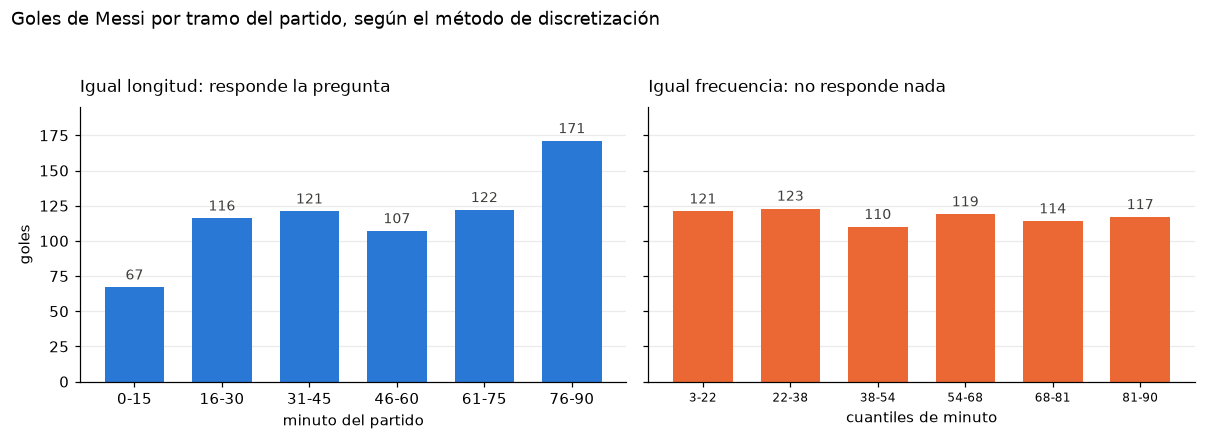

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

etiquetas = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90"]
b1 = ax1.bar(etiquetas, igual_longitud.values, color=AZUL, width=0.68)
ax1.set_title("Igual longitud: responde la pregunta", fontsize=11, loc="left", pad=10)
ax1.set_xlabel("minuto del partido")
ax1.set_ylabel("goles")
ax1.bar_label(b1, padding=3, fontsize=9, color="#3d3d3a")

b2 = ax2.bar(range(6), igual_frecuencia.values, color=NARANJA, width=0.68)
ax2.set_title("Igual frecuencia: no responde nada", fontsize=11, loc="left", pad=10)
ax2.set_xlabel("cuantiles de minuto")
ax2.set_xticks(range(6), [str(i.left.round()).rstrip("0").rstrip(".") + "-" + str(i.right.round()).rstrip("0").rstrip(".")
                          for i in igual_frecuencia.index], fontsize=8)
ax2.bar_label(b2, padding=3, fontsize=9, color="#3d3d3a")

for ax in (ax1, ax2):
    ax.set_ylim(0, 195)
    ax.grid(axis="x", visible=False)

fig.suptitle("Goles de Messi por tramo del partido, según el método de discretización",
             fontsize=12, x=0.008, ha="left", y=1.04)
plt.tight_layout()
plt.show()

El contraste es el argumento de la respuesta:

- **Igual longitud** muestra un hallazgo real: el último cuarto de hora es de lejos el más
  goleador, con más del doble de goles que los primeros quince minutos.
- **Igual frecuencia** deja los seis grupos casi planos, porque `qcut` **por construcción**
  pone la misma cantidad de observaciones en cada intervalo. Si todos los tramos tienen los
  mismos goles, es imposible saber en cuál convierte más.

El teórico lo define así en la diapositiva 18 del deck *06 - Procesamiento y nuevas features*:

| Método | Descripción |
|---|---|
| **Intervalos iguales** | *"Rangos de igual amplitud"* |
| Por puntos de corte | *"Basados en la distribución de los datos. **Cada intervalo tiene el mismo número de observaciones**"* |

Las otras dos opciones ni siquiera producen tramos: *Target Encoding* es para variables
categóricas, y *estandarizar* solo cambia la escala, no agrupa nada.

## Pregunta 9 — La variable target `Has_Assist`

> Se desea entrenar un modelo para predecir `Has_Assist`. Antes de entrenar, analizá la
> variable target. ¿Cuál de las siguientes afirmaciones es correcta?

**Respuesta: el dataset está ligeramente desbalanceado.**

Hay que chequear dos cosas: si tiene nulos y cómo se reparten las clases.

In [20]:
print("Nulos en Has_Assist :", df["Has_Assist"].isna().sum())
print("Tipo                :", df["Has_Assist"].dtype)
print("Valores posibles    :", sorted(df["Has_Assist"].unique()))

conteo = df["Has_Assist"].value_counts().sort_index()
balance = pd.DataFrame({
    "goles": conteo,
    "%": (df["Has_Assist"].value_counts(normalize=True).sort_index() * 100).round(2),
})
balance.index = ["0 = sin asistencia", "1 = con asistencia"]
print()
print(balance)
print(f"\nRazón mayoritaria : minoritaria = {conteo.max() / conteo.min():.2f} : 1")

Nulos en Has_Assist : 0
Tipo                : int64
Valores posibles    : [np.int64(0), np.int64(1)]

                    goles     %
0 = sin asistencia    214  30.4
1 = con asistencia    490  69.6

Razón mayoritaria : minoritaria = 2.29 : 1


Con eso se descartan las tres opciones incorrectas:

| Opción | Veredicto |
|---|---|
| *"La variable tiene nulos y deben ser tratados"* | **Falsa.** `Has_Assist` tiene **cero** nulos |
| *"Muy desbalanceado (más del 80 % tuvo asistencia)"* | **Falsa.** Es 69.6 %, no supera el 80 % |
| *"Muy desbalanceado (menos del 10 % tuvo asistencia)"* | **Falsa.** Está lejísimos del 10 % |
| ***"Ligeramente desbalanceado"*** | **Correcta.** 69.6 / 30.4, razón 2.29 : 1 |

### La trampa de la primera opción

La columna que **sí** tiene 214 nulos es `Goal_assist`, el nombre del jugador que asistió.
No es la misma columna que `Has_Assist`. Y esos nulos son **estructurales**: faltan porque
el gol no tuvo asistencia, no porque se haya perdido el dato.

In [21]:
print("Coincidencia entre el nulo de Goal_assist y el cero de Has_Assist:")
print(pd.crosstab(df["Goal_assist"].isna(), df["Has_Assist"],
                  rownames=["Goal_assist es nulo"], colnames=["Has_Assist"]))

coincide = (df["Goal_assist"].isna() == (df["Has_Assist"] == 0)).all()
print(f"\n¿Coinciden exactamente en las 704 filas? {coincide}")
print("La diagonal vacía lo confirma: no hay un solo caso cruzado.")
print("Son faltantes estructurales -> no se imputan, se interpretan.")

Coincidencia entre el nulo de Goal_assist y el cero de Has_Assist:
Has_Assist             0    1
Goal_assist es nulo          
False                  0  490
True                 214    0

¿Coinciden exactamente en las 704 filas? True
La diagonal vacía lo confirma: no hay un solo caso cruzado.
Son faltantes estructurales -> no se imputan, se interpretan.


# Anexo — Un error del dataset que no entra en las preguntas

Analizando el CSV apareció un problema serio que conviene tener identificado.

El dataset dice que **Messi marcó en 254 partidos perdidos**, el 36 % de sus goles. Eso es
implausible para cualquier delantero, y menos para el de este equipo. Vale la pena mirarlo.

In [22]:
print("Resultado del partido según el dataset:")
print(df["Match_Result"].value_counts().to_string())
print("\nMismo dato, abierto por localía:")
print(pd.crosstab(df["Venue"], df["Match_Result"], margins=True).to_string())

Resultado del partido según el dataset:
Match_Result
Win     395
Loss    254
Draw     55

Mismo dato, abierto por localía:
Match_Result  Draw  Loss  Win  All
Venue                             
A               30   243   11  284
H               25    11  384  420
All             55   254  395  704


Ahí salta: de local gana el 91 % de las veces, pero **de visitante el dataset dice que pierde
el 86 %**. Un equipo no cambia así. El problema está en cómo se leyó el marcador.

In [23]:
# El caso testigo: Atlético de Madrid 0-6 Barcelona, mayo de 2007.
caso = df[(df["Opponent"] == "Atletico de Madrid") & (df["Result"] == "0:06")]
caso[["Date", "Opponent", "Venue", "Result", "Goals_For", "Goals_Against", "Match_Result"]]

,Date,Opponent,Venue,Result,Goals_For,Goals_Against,Match_Result
20,5/20/07,Atletico de Madrid,A,0:06,0,6,Loss
21,5/20/07,Atletico de Madrid,A,0:06,0,6,Loss


Ese partido **Barcelona lo ganó 6 a 0**. El dataset lo registra como derrota con cero goles
a favor, porque el marcador viene escrito en formato **local : visitante**, y al ser partido
de visitante el primer número es del rival. `Goals_For` y `Goals_Against` están invertidos
en todos los partidos de visitante.

Hay una prueba lógica todavía más fuerte: si la fila existe es porque **Messi acaba de
marcar**, así que su equipo no puede tener cero goles.

In [24]:
imposibles = (df["Score_For"] == 0).sum()
print(f"Filas donde el equipo de Messi tiene 0 goles justo después de que Messi marcara: {imposibles}")
print("\nY todas son de visitante:")
print(pd.crosstab(df["Venue"], df["Score_For"] == 0,
                  rownames=["Venue"], colnames=["Score_For == 0"]).to_string())

Filas donde el equipo de Messi tiene 0 goles justo después de que Messi marcara: 188

Y todas son de visitante:
Score_For == 0  False  True 
Venue                       
A                  96    188
H                 420      0


In [25]:
# Corrección: en los partidos de visitante hay que dar vuelta el marcador.
visitante = df["Venue"] == "A"
gf = np.where(visitante, df["Goals_Against"], df["Goals_For"])
ga = np.where(visitante, df["Goals_For"], df["Goals_Against"])
resultado_ok = np.where(gf > ga, "Win", np.where(gf < ga, "Loss", "Draw"))

comparacion = pd.DataFrame({
    "dataset (%)": df["Match_Result"].value_counts(normalize=True).mul(100).round(1),
    "corregido (%)": pd.Series(resultado_ok).value_counts(normalize=True).mul(100).round(1),
})
print(comparacion.to_string())
print(f"\nGoles en partidos perdidos:  dataset {(df['Match_Result'] == 'Loss').sum()}"
      f"  ->  corregido {(resultado_ok == 'Loss').sum()}")

      dataset (%)  corregido (%)
Draw          7.8            7.8
Loss         36.1            3.1
Win          56.1           89.1

Goles en partidos perdidos:  dataset 254  ->  corregido 22


Corregido da **89 % de victorias y 3 % de derrotas**, que sí es un número razonable.

Las columnas afectadas por esta inversión son `Goals_For`, `Goals_Against`, `Match_Result`,
`Score_For`, `Score_Against` y `Score_Diff`. Todas derivadas, todas mal para los 284 goles
de visitante. Es un buen ejemplo de por qué las variables derivadas se auditan contra una
regla del dominio antes de usarlas.

**Nota:** ninguna de las 9 preguntas de la actividad usa estas columnas, así que las
respuestas marcadas no se ven afectadas.

---

## Resumen

| # | Respuesta | De dónde sale |
|---|---|---|
| 1 | Imputar con media/mediana considerando el patrón | Deck 05, diapositiva 21: MAR + 10-30 % |
| 2 | Mantiene la misma proporción de clases | Deck 05, diapositiva 9 |
| 3 | Evita contaminar el train y las métricas optimistas | Deck 06, diapositiva 5 |
| 4 | KNN es sensible a la escala | Deck 06, diapositiva 39 |
| 5 | Balanceo por oversampling (SMOTE) | Deck 06, diapositivas 31 y 32 |
| 6 | Limpiar la columna y después codificar | 9 categorías que son 5 |
| 7 | Frequency o Target Encoding | 98 rivales = alta cardinalidad |
| 8 | Intervalos de igual longitud | `qcut` aplana los tramos y no responde |
| 9 | Ligeramente desbalanceado | 69.6 / 30.4, sin nulos |